# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## テールの内訳とウェイト方式

### 目的

`04_quantile` で、RRI の情報は「25 以上（RepRisk の「中」以上）の劣後」に集中し、サイズを揃えても残ることが分かった。
ここでは中型・大型（サイズ分位 S3〜S5）に絞って、

1. 3 群（ゼロ / 1–24 / 25 以上）の結果が **ウェイト方式**（等ウェイト / Root Cap / Cap Weight）に依存しないか
2. **25 以上の内側に用量反応**（RRI が高いほど劣後）があるか

を確認する。1 は「効果が群内の小さめの銘柄に依存していないか」、2 は「水準を使うスクリーンにするか、
25 以上かどうかの二値フラグにするか」の判断材料になる。

### 定義

- セグメント: サイズ 5 分位（`univ/` のウェイトの対数順位）の S3〜S5。確認用にベンチマーク内（MSCI India 構成銘柄）も併記
- ウェイト方式（`alphaeval.weight_portfolio`）
  - 等ウェイト: $w_i = 1/n$
  - Root Cap: $w_i \propto \sqrt{M_i}$
  - Cap Weight: $w_i \propto M_i$、ただし 1 銘柄上限 10%（`docs/india_tcg.md` §3.5 の反復で再配分）
  - $M_i$ はユニバースウェイト（浮動株調整後時価総額に比例）
- 参照: **同じセグメント・同じウェイト方式**で作ったスコアあり銘柄のポートフォリオ。方式ごとに参照を変えることで
  サイズ効果を混ぜずに群選択の効果を測る
- 25 以上の内訳
  - 水準 2 分割: 25–34 / 35 以上（RepRisk の区分に近い）
  - 順位 2 分割・3 分割: 25 以上の中で RRI の順位により上下（スコア水準のトレンドに影響されない）
- リターンは `rtn`（INR 建てトータルリターン）。方向は RRI が低いほど良いと仮定

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, performance_summary, portfolio_returns, turnover, weight_portfolio

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)

# ---- パラメータ
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
BENCHMARK = "msci_india"
RISK_MODEL, RETURN_COL = "GEMLT", "rtn"
START, END = 200801, 202606
N_SIZE_BINS = 5
SIZE_BINS_USED = [3, 4, 5]
MAX_WEIGHT = 0.10
TAIL = 24.5                       # 「25 以上」の下限
BANDS = {"ゼロ": (-0.5, 0.5), "1–24": (0.5, TAIL), "25以上": (TAIL, 1000)}
SCHEMES = {"等ウェイト": ("equal", None), "Root Cap": ("sqrt_size", MAX_WEIGHT), "Cap Weight": ("size", MAX_WEIGHT)}
LATE_START = "2013-01-01"         # 銘柄数が少ない初期を除いたサブ期間

store = InputStore(INPUT_ROOT)

### 1. データ読み込みとセグメント定義

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
score = store.alpha(SCORE, START, END)
rtn = store.returns(RISK_MODEL, RETURN_COL, START, 202607)

score_u = score.where(univ.notna()).reindex(columns=univ.columns)   # 列をユニバースに揃える
log_size = np.log(univ.where(univ > 0))
size_bin = np.ceil(log_size.rank(axis=1, pct=True) * N_SIZE_BINS).clip(1, N_SIZE_BINS)
in_bm = bm.reindex(index=univ.index, columns=univ.columns).notna()

segments = {
    "S3–S5": size_bin.isin(SIZE_BINS_USED),
    "ベンチマーク内": in_bm,
}
bm_ret = portfolio_returns(bm, rtn)
print(f"期間: {univ.index.min().date()} 〜 {univ.index.max().date()} ({len(univ)} か月)")
for name, seg in segments.items():
    s = score_u.where(seg)
    print(f"{name}: 平均銘柄数 {seg.sum(axis=1).mean():.0f}, スコアあり {s.notna().sum(axis=1).mean():.0f}, 25以上 {(s >= TAIL).sum(axis=1).mean():.1f}")

期間: 2008-01-31 〜 2026-06-30 (222 か月)
S3–S5: 平均銘柄数 225, スコアあり 178, 25以上 17.5
ベンチマーク内: 平均銘柄数 89, スコアあり 84, 25以上 13.8


分析用のヘルパー。組入判定（bool パネル）とウェイト方式からポートフォリオを作り、参照との差を集計する。

In [3]:
def build(member: pd.DataFrame, scheme_key: str) -> pd.DataFrame:
    scheme, cap = SCHEMES[scheme_key]
    return weight_portfolio(member.fillna(False), scheme, size=univ, max_weight=cap)


def evaluate(members: dict[str, pd.DataFrame], ref_member: pd.DataFrame, scheme_key: str, start: str | None = None) -> pd.DataFrame:
    """各グループを scheme_key で構築し、同方式の参照（ref_member）と比較した指標表を返す。"""
    ref_ret = portfolio_returns(build(ref_member, scheme_key), rtn)
    rows = {}
    for name, m in members.items():
        w = build(m, scheme_key)
        r = portfolio_returns(w, rtn)
        to = turnover(w, rtn)
        n = m.sum(axis=1)
        if start is not None:
            r, to, n = r.loc[start:], to.loc[start:], n.loc[start:]
        base = performance_summary(r, bm_ret.reindex(r.index), to)
        ref = performance_summary(r, ref_ret.reindex(r.index))
        rows[name] = pd.Series(
            {
                "年率リターン": base["ann_return"],
                "年率リスク": base["ann_volatility"],
                "R/R": base["return_risk"],
                "年率回転率": base["turnover_annual"],
                "平均銘柄数": n.mean(),
                "最小銘柄数": n.min(),
                "5銘柄未満の月割合": (n < 5).mean(),
                "超過(vs 参照)": ref["active_return"],
                "TE(vs 参照)": ref["tracking_error"],
                "IR(vs 参照)": ref["information_ratio"],
                "勝率(vs 参照)": ref["active_hit_rate"],
                "超過(vs BM)": base["active_return"],
                "IR(vs BM)": base["information_ratio"],
            }
        )
    return pd.DataFrame(rows)


def compare_schemes(members: dict[str, pd.DataFrame], ref_member: pd.DataFrame, rows: list[str], start: str | None = None) -> pd.DataFrame:
    """3 方式の指標を横に並べる（列: 方式 × グループ）。"""
    out = {}
    for key in SCHEMES:
        t = evaluate(members, ref_member, key, start)
        for g in t.columns:
            out[(key, g)] = t[g].reindex(rows)
    df = pd.DataFrame(out)
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=["方式", "グループ"])
    return df


def spread_stats(members: dict[str, pd.DataFrame], long: str, short: str, start: str | None = None) -> pd.DataFrame:
    """long − short のスプレッドを 3 方式で集計する。"""
    rows = {}
    for key in SCHEMES:
        rl = portfolio_returns(build(members[long], key), rtn)
        rs = portfolio_returns(build(members[short], key), rtn)
        z = (rl - rs).dropna()
        if start is not None:
            z = z.loc[start:]
        rows[key] = {"年率": z.mean() * 12, "年率リスク": z.std() * np.sqrt(12), "R/R": z.mean() / z.std() * np.sqrt(12), "勝率": (z > 0).mean(), "月数": len(z)}
    return pd.DataFrame(rows).T


def plot_relative(members: dict[str, pd.DataFrame], ref_member: pd.DataFrame, title: str) -> None:
    """3 方式それぞれについて参照に対する累積相対リターンを描く。"""
    fig, axes = plt.subplots(1, len(SCHEMES), figsize=(15, 4), sharey=True)
    for ax, key in zip(axes, SCHEMES):
        ref = portfolio_returns(build(ref_member, key), rtn)
        for name, m in members.items():
            r = portfolio_returns(build(m, key), rtn)
            rel = (1 + r).cumprod() / (1 + ref.reindex(r.index)).cumprod()
            ax.plot(rel.index, rel, label=name)
        ax.axhline(1, color="k", linewidth=0.8)
        ax.set_yscale("log")
        ax.set_title(f"{title}: {key}")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("累積相対リターン（対数）")
    axes[0].legend()
    plt.tight_layout()
    plt.show()


def band_members(s: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {name: (s >= lo) & (s < hi) for name, (lo, hi) in BANDS.items()}


METRIC_ROWS = ["年率リターン", "年率リスク", "R/R", "年率回転率", "平均銘柄数", "最小銘柄数", "5銘柄未満の月割合", "超過(vs 参照)", "TE(vs 参照)", "IR(vs 参照)", "勝率(vs 参照)"]

### 2. 3 群 × ウェイト方式（S3〜S5）

参照は S3〜S5 のスコアあり銘柄を同じ方式で組んだポートフォリオ。

方式          等ウェイト                 Root Cap                 Cap Weight                
グループ           ゼロ    1–24    25以上       ゼロ    1–24    25以上         ゼロ    1–24    25以上
年率リターン      0.129   0.118   0.042    0.126   0.114   0.048      0.122   0.109   0.047
年率リスク       0.261   0.248   0.273    0.246   0.219   0.263      0.232   0.204   0.260
R/R         0.494   0.478   0.153    0.511   0.518   0.183      0.525   0.534   0.180
年率回転率       1.188   1.861   6.252    0.952   1.781   6.004      0.924   1.921   5.902
平均銘柄数      83.032  77.311  17.468   83.032  77.311  17.468     83.032  77.311  17.468
最小銘柄数      40.000  21.000   2.000   40.000  21.000   2.000     40.000  21.000   2.000
5銘柄未満の月割合   0.000   0.000   0.045    0.000   0.000   0.045      0.000   0.000   0.045
超過(vs 参照)   0.014   0.001  -0.062    0.020   0.003  -0.046      0.026   0.007  -0.037
TE(vs 参照)   0.037   0.041   0.109    0.046   0.037   0.103      0.067   0.035   0.118
IR(vs 参照)   0.388   0.019  -0.571    0.440   0.074  -0.452      0.383   0.195  -0.310
勝率(vs 参照)   0.518   0.473   0.446    0.568   0.437   0.455      0.568   0.468   0.450

スプレッド: ゼロ − 25以上


,年率,年率リスク,R/R,勝率,月数
等ウェイト,0.077,0.131,0.583,0.532,222.0
Root Cap,0.067,0.124,0.540,0.532,222.0
Cap Weight,0.062,0.127,0.491,0.559,222.0


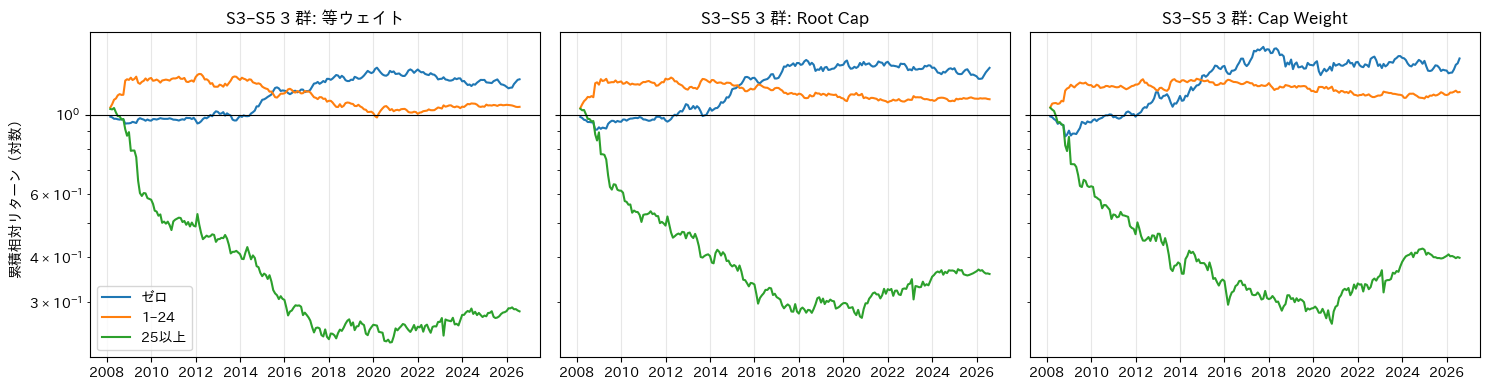

In [4]:
seg = segments["S3–S5"]
s_seg = score_u.where(seg)
members3 = band_members(s_seg)
ref3 = s_seg.notna()

display(compare_schemes(members3, ref3, METRIC_ROWS).round(3))
print("スプレッド: ゼロ − 25以上")
display(spread_stats(members3, "ゼロ", "25以上").round(3))
plot_relative(members3, ref3, "S3–S5 3 群")

同じ集計を 2013 年以降（25 以上の銘柄数が 10 を超えてからの期間）で行う。

In [5]:
display(compare_schemes(members3, ref3, ["年率リターン", "平均銘柄数", "超過(vs 参照)", "IR(vs 参照)", "勝率(vs 参照)"], start=LATE_START).round(3))
print(f"スプレッド: ゼロ − 25以上（{LATE_START} 以降）")
display(spread_stats(members3, "ゼロ", "25以上", start=LATE_START).round(3))

方式          等ウェイト                 Root Cap                 Cap Weight                
グループ           ゼロ    1–24    25以上       ゼロ    1–24    25以上         ゼロ    1–24    25以上
年率リターン      0.167   0.138   0.110    0.159   0.134   0.117      0.147   0.128   0.116
平均銘柄数      75.290  88.586  19.920   75.290  88.586  19.920     75.290  88.586  19.920
超過(vs 参照)   0.017  -0.010  -0.028    0.021  -0.006  -0.012      0.021  -0.001  -0.001
IR(vs 参照)   0.449  -0.318  -0.300    0.437  -0.199  -0.125      0.302  -0.046  -0.013
勝率(vs 参照)   0.534   0.429   0.466    0.595   0.405   0.491      0.558   0.442   0.528

スプレッド: ゼロ − 25以上（2013-01-01 以降）


,年率,年率リスク,R/R,勝率,月数
等ウェイト,0.045,0.118,0.385,0.521,163.0
Root Cap,0.033,0.116,0.282,0.503,163.0
Cap Weight,0.023,0.123,0.186,0.497,163.0


確認用: ベンチマーク内で同じ比較。

In [6]:
seg_bm = segments["ベンチマーク内"]
s_bm = score_u.where(seg_bm)
members3_bm = band_members(s_bm)
display(compare_schemes(members3_bm, s_bm.notna(), ["年率リターン", "平均銘柄数", "年率回転率", "超過(vs 参照)", "IR(vs 参照)", "勝率(vs 参照)"]).round(3))
print("スプレッド: ゼロ − 25以上（ベンチマーク内）")
display(spread_stats(members3_bm, "ゼロ", "25以上").round(3))

方式          等ウェイト                 Root Cap                 Cap Weight                
グループ           ゼロ    1–24    25以上       ゼロ    1–24    25以上         ゼロ    1–24    25以上
年率リターン      0.112   0.118   0.058    0.109   0.110   0.055      0.109   0.107   0.052
平均銘柄数      22.815  46.986  13.811   22.815  46.986  13.811     22.815  46.986  13.811
年率回転率       1.074   1.912   5.840    1.004   1.864   5.786      1.027   1.972   5.766
超過(vs 参照)   0.008   0.011  -0.034    0.012   0.008  -0.030      0.016   0.007  -0.029
IR(vs 参照)   0.133   0.294  -0.311    0.188   0.230  -0.271      0.208   0.207  -0.235
勝率(vs 参照)   0.477   0.491   0.455    0.500   0.473   0.491      0.550   0.464   0.473

スプレッド: ゼロ − 25以上（ベンチマーク内）


,年率,年率リスク,R/R,勝率,月数
等ウェイト,0.042,0.146,0.288,0.514,222.0
Root Cap,0.042,0.143,0.294,0.527,222.0
Cap Weight,0.045,0.145,0.313,0.523,222.0


### 3. 25 以上の内訳（S3〜S5）

25 以上の銘柄数の推移を見てから、水準 2 分割（25–34 / 35 以上）と順位 2 分割・3 分割を比較する。
参照は「25 以上」全体（同方式）。つまり、テールの中で RRI が高い側がテール全体よりさらに劣後するかを見る。

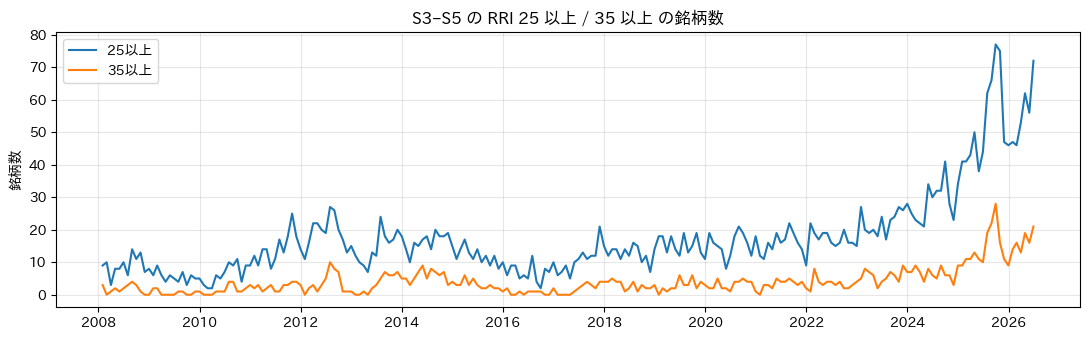

25以上: 平均 17.5, 最小 2, 最大 77, 10 銘柄未満の月 23.4%


In [7]:
tail = s_seg.where(s_seg >= TAIL)
n_tail = tail.notna().sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(n_tail.index, n_tail, label="25以上")
ax.plot(n_tail.index, (tail >= 34.5).sum(axis=1), label="35以上")
ax.set_ylabel("銘柄数")
ax.set_title("S3–S5 の RRI 25 以上 / 35 以上 の銘柄数")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"25以上: 平均 {n_tail.mean():.1f}, 最小 {n_tail.min()}, 最大 {n_tail.max()}, 10 銘柄未満の月 {(n_tail < 10).mean():.1%}")

In [8]:
# 水準 2 分割
members_level = {"25–34": (tail >= TAIL) & (tail < 34.5), "35以上": tail >= 34.5}
# 順位 2 分割・3 分割（25 以上の中でのパーセンタイル順位。高 RRI が上位）
pct_tail = tail.rank(axis=1, pct=True)
members_rank2 = {"下位半分(低)": pct_tail <= 0.5, "上位半分(高)": pct_tail > 0.5}
members_rank3 = {"T1(低)": pct_tail <= 1 / 3, "T2": (pct_tail > 1 / 3) & (pct_tail <= 2 / 3), "T3(高)": pct_tail > 2 / 3}
ref_tail = tail.notna()

print("水準 2 分割（参照 = 25以上 全体）")
display(compare_schemes(members_level, ref_tail, METRIC_ROWS).round(3))
print("スプレッド: 25–34 − 35以上")
display(spread_stats(members_level, "25–34", "35以上").round(3))

水準 2 分割（参照 = 25以上 全体）


方式          等ウェイト        Root Cap        Cap Weight       
グループ        25–34   35以上    25–34   35以上      25–34   35以上
年率リターン      0.043 -0.012    0.052 -0.013      0.054 -0.013
年率リスク       0.274  0.310    0.268  0.310      0.267  0.310
R/R         0.155 -0.038    0.195 -0.043      0.203 -0.042
年率回転率       8.452  6.388    8.274  6.378      8.224  6.375
平均銘柄数      13.414  4.054   13.414  4.054     13.414  4.054
最小銘柄数       1.000  0.000    1.000  0.000      1.000  0.000
5銘柄未満の月割合   0.081  0.703    0.081  0.703      0.081  0.703
超過(vs 参照)   0.000 -0.040    0.005 -0.045      0.008 -0.043
TE(vs 参照)   0.060  0.216    0.061  0.218      0.063  0.221
IR(vs 参照)   0.006 -0.186    0.080 -0.206      0.129 -0.194
勝率(vs 参照)   0.468  0.464    0.468  0.459      0.455  0.455

スプレッド: 25–34 − 35以上


,年率,年率リスク,R/R,勝率,月数
等ウェイト,0.041,0.262,0.155,0.536,222.0
Root Cap,0.050,0.261,0.190,0.541,222.0
Cap Weight,0.051,0.262,0.194,0.550,222.0


順位 2 分割（参照 = 25以上 全体）


方式          等ウェイト         Root Cap         Cap Weight        
グループ      下位半分(低) 上位半分(高)  下位半分(低) 上位半分(高)    下位半分(低) 上位半分(高)
年率リターン      0.036   0.028    0.036   0.023      0.036   0.021
年率リスク       0.268   0.317    0.267   0.316      0.267   0.316
R/R         0.132   0.088    0.133   0.074      0.133   0.067
年率回転率      10.367   7.145   10.326   6.990     10.317   6.939
平均銘柄数       8.541   8.928    8.541   8.928      8.541   8.928
最小銘柄数       0.000   1.000    0.000   1.000      0.000   1.000
5銘柄未満の月割合   0.203   0.216    0.203   0.216      0.203   0.216
超過(vs 参照)  -0.008  -0.001   -0.012  -0.008     -0.010  -0.009
TE(vs 参照)   0.109   0.106    0.114   0.109      0.118   0.113
IR(vs 参照)  -0.076  -0.005   -0.102  -0.076     -0.085  -0.076
勝率(vs 参照)   0.491   0.505    0.491   0.477      0.491   0.468

スプレッド: 下位半分 − 上位半分


,年率,年率リスク,R/R,勝率,月数
等ウェイト,-0.008,0.213,-0.036,0.491,222.0
Root Cap,-0.003,0.213,-0.016,0.509,222.0
Cap Weight,-0.001,0.213,-0.006,0.514,222.0


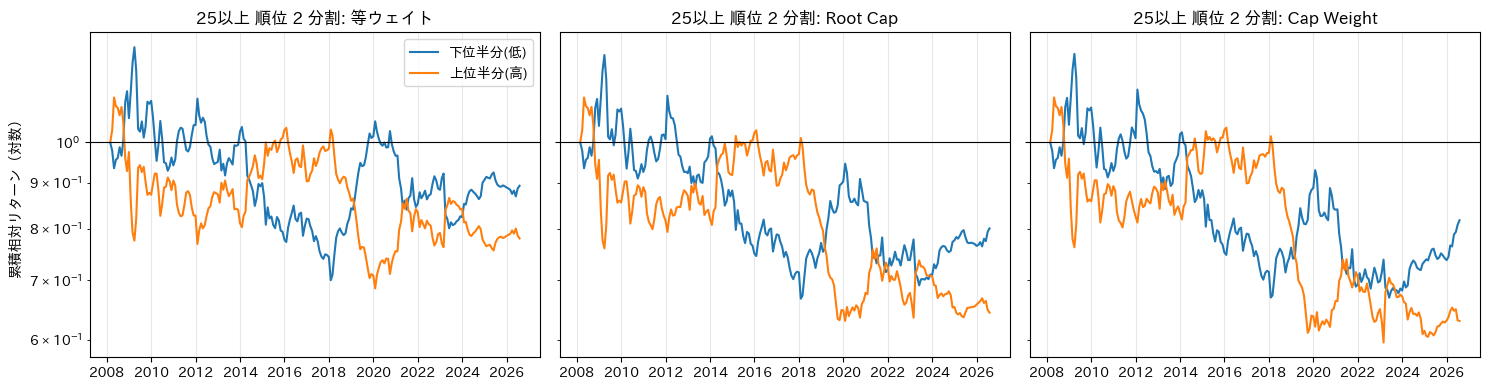

In [9]:
print("順位 2 分割（参照 = 25以上 全体）")
display(compare_schemes(members_rank2, ref_tail, METRIC_ROWS).round(3))
print("スプレッド: 下位半分 − 上位半分")
display(spread_stats(members_rank2, "下位半分(低)", "上位半分(高)").round(3))
plot_relative(members_rank2, ref_tail, "25以上 順位 2 分割")

In [10]:
print("順位 3 分割（参照 = 25以上 全体）")
display(compare_schemes(members_rank3, ref_tail, ["年率リターン", "平均銘柄数", "最小銘柄数", "5銘柄未満の月割合", "超過(vs 参照)", "IR(vs 参照)", "勝率(vs 参照)"]).round(3))
print("スプレッド: T1 − T3")
display(spread_stats(members_rank3, "T1(低)", "T3(高)").round(3))
print(f"順位 2 分割スプレッド（{LATE_START} 以降）")
display(spread_stats(members_rank2, "下位半分(低)", "上位半分(高)", start=LATE_START).round(3))

順位 3 分割（参照 = 25以上 全体）


方式         等ウェイト               Root Cap               Cap Weight              
グループ       T1(低)     T2  T3(高)    T1(低)     T2  T3(高)      T1(低)     T2  T3(高)
年率リターン     0.044  0.038  0.012    0.046  0.038  0.010      0.047  0.038  0.010
平均銘柄数      5.739  5.482  6.248    5.739  5.482  6.248      5.739  5.482  6.248
最小銘柄数      0.000  0.000  1.000    0.000  0.000  1.000      0.000  0.000  1.000
5銘柄未満の月割合  0.441  0.509  0.374    0.441  0.509  0.374      0.441  0.509  0.374
超過(vs 参照)  0.003  0.004 -0.011    0.001  0.001 -0.016      0.004  0.003 -0.015
IR(vs 参照)  0.017  0.026 -0.080    0.008  0.006 -0.117      0.023  0.017 -0.102
勝率(vs 参照)  0.491  0.491  0.500    0.486  0.509  0.495      0.486  0.523  0.495

スプレッド: T1 − T3


,年率,年率リスク,R/R,勝率,月数
等ウェイト,0.013,0.259,0.052,0.532,222.0
Root Cap,0.018,0.259,0.068,0.527,222.0
Cap Weight,0.018,0.259,0.071,0.532,222.0


順位 2 分割スプレッド（2013-01-01 以降）


,年率,年率リスク,R/R,勝率,月数
等ウェイト,0.000,0.177,0.001,0.491,163.0
Root Cap,0.008,0.177,0.044,0.515,163.0
Cap Weight,0.011,0.177,0.062,0.521,163.0


### 4. 年別の安定性

「ゼロ − 25 以上」（S3〜S5）と「25 以上の下位半分 − 上位半分」の年別スプレッドを 3 方式で並べる。

ゼロ − 25以上                     25以上: 下位半分 − 上位半分                    
         等ウェイト Root Cap Cap Weight             等ウェイト Root Cap Cap Weight
2008     0.024   -0.002     -0.007            -0.067   -0.067     -0.067
2009     0.590    0.509      0.425            -0.091   -0.091     -0.091
2010     0.141    0.170      0.222            -0.216   -0.216     -0.216
2011     0.023    0.056      0.127             0.196    0.173      0.164
2012     0.098    0.127      0.136            -0.133   -0.132     -0.132
2013     0.061    0.119      0.161             0.158    0.153      0.158
2014     0.265    0.193      0.114            -0.255   -0.255     -0.255
2015     0.221    0.196      0.184            -0.263   -0.263     -0.263
2016     0.080    0.059      0.034             0.174    0.174      0.174
2017     0.251    0.213      0.166            -0.173   -0.169     -0.168
2018    -0.086   -0.090     -0.063             0.262    0.262      0.262
2019     0.025    0.011      0.015             0.454    0.454      0.454
2020    -0.011   -0.015     -0.022            -0.117   -0.105     -0.103
2021     0.011   -0.081     -0.132            -0.229   -0.244     -0.254
2022    -0.094   -0.086     -0.067             0.088    0.091      0.091
2023    -0.099   -0.077     -0.089            -0.177   -0.139     -0.122
2024     0.011   -0.040     -0.097             0.198    0.181      0.175
2025    -0.069   -0.046     -0.018            -0.040   -0.023     -0.025
2026     0.059    0.080      0.097             0.014    0.073      0.115

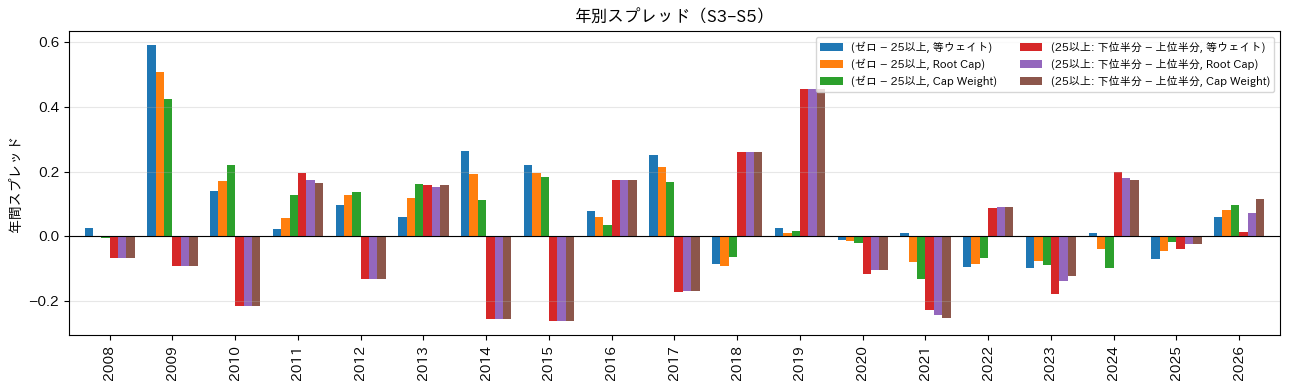

In [11]:
def yearly_spread(members: dict[str, pd.DataFrame], long: str, short: str) -> pd.DataFrame:
    out = {}
    for key in SCHEMES:
        z = portfolio_returns(build(members[long], key), rtn) - portfolio_returns(build(members[short], key), rtn)
        out[key] = z.groupby(z.index.year).apply(lambda x: (1 + x).prod() - 1)
    return pd.DataFrame(out)

ys = pd.concat(
    {"ゼロ − 25以上": yearly_spread(members3, "ゼロ", "25以上"), "25以上: 下位半分 − 上位半分": yearly_spread(members_rank2, "下位半分(低)", "上位半分(高)")},
    axis=1,
)
display(ys.round(3))
ax = ys.plot.bar(figsize=(13, 4), width=0.8)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("年間スプレッド")
ax.set_title("年別スプレッド（S3–S5）")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### 5. 所見

**3 群 × ウェイト方式（S3〜S5、参照は同方式のスコアあり銘柄）**

| ゼロ − 25 以上 | 等ウェイト | Root Cap | Cap Weight（10% 上限） |
| --- | --- | --- | --- |
| 年率（全期間） | 7.7% | 6.7% | 6.2% |
| R/R（全期間） | 0.58 | 0.54 | 0.49 |
| 年率（2013 年以降） | 4.5% | 3.3% | 2.3% |
| 25 以上の対参照超過（2013 年以降） | −2.8% | −1.2% | −0.1% |

- 全期間では方式によらず「25 以上」が参照に対して年率 −3.7〜−6.2% 劣後し、ゼロ − 25 以上のスプレッドは
  R/R 0.5〜0.6。**効果は群内の小さめの銘柄だけに依存しているわけではない**が、Cap Weight ほど弱まる。
- ただし 2013 年以降に限ると Cap Weight では 25 以上の劣後がほぼ消える（−0.1%、IR −0.01）。
  等ウェイトでも −2.8%（IR −0.30）まで縮む。**時価総額の大きい高 RRI 銘柄は、近年は劣後していない**。
- ベンチマーク内では 3 方式とも年率 4.2〜4.5%、R/R 0.29〜0.31 で方式間の差は小さい。
- ゼロ群の対参照超過は +1.4〜2.6% と小さいが 3 方式で正。1–24 群はほぼゼロ。

**25 以上の内訳（S3〜S5）**

- 25 以上は平均 17.5 銘柄、最小 2、10 銘柄未満の月が 23%。内訳を切るとさらに少なく、
  「35 以上」は平均 4 銘柄で 70% の月が 5 銘柄未満、順位 3 分割は各群 5〜6 銘柄。統計的に信頼できる水準ではない。
- 水準 2 分割: 35 以上は 25–34 に対して年率 −4〜−5% 劣後するが、4 銘柄の結果であり R/R 0.15〜0.19。
- 順位 2 分割: スプレッドは年率 −0.8〜−0.1%、R/R ≈ 0。3 分割の T1 − T3 も年率 1〜2%、R/R 0.05〜0.07。
  年別では符号が毎年のように入れ替わる（2018 年 +26%、2019 年 +45%、2021 年 −23%、2014 年 −26%）。
- **テールの中に用量反応は確認できない**。「35 以上」の劣後は示唆的だが銘柄数が少なすぎる。
  RRI は「25 以上かどうか」の二値フラグとして扱うのが妥当。

**年別の安定性**

- ゼロ − 25 以上は 2008〜2017 年の 10 年間すべて正（2009 年 +59%、2014 年 +27%、2017 年 +25%）。
  2018〜2025 年は 8 年中 5 年（2018、2020、2021、2022、2023、2025 の多く）で負、正の年も小さい。
- 2013 年以降で効果が弱まるのは、初期（2008〜2012 年）の寄与が大きいことに加え、**2018 年以降は効果が消失している**ため。
  25 以上の銘柄数が 2008 年の 9 から 2026 年の 60 超へ増えており、RepRisk のカバレッジ拡張で「25 以上」の意味が
  変わった可能性（初期は本当に問題のある少数の企業、近年は報道量の多い大企業一般）が高い。

**まとめと後続ステップ**

1. 方式依存は小さく、等ウェイトの結果は Root Cap でもおおむね再現する。運用上は Root Cap を基準にしてよい。
2. テールの内側には情報が無いので、RRI は「25 以上（またはクロスセクション上位 x%）を除外する二値スクリーン」として設計する。
3. 最大の論点は **2018 年以降の消失**。次のステップとして、
   - 閾値をクロスセクションの上位 x%（例: 上位 5% / 10%）で定義し直し、水準ではなく順位で「テール」を決めた場合に
     2018 年以降も効果が残るかを確認する
   - 「25 以上」の構成（業種、サイズ、時価総額シェア）が 2018 年前後でどう変わったかを確認する
     （業種は `input` に無いため、必要なら `data/universe` の GICS を追加する）
   - IC（Spearman、25 以上ダミーとの相関、上位 x% ダミーとの相関）を期間別に出す